# Final Model Comparison

This notebook compares the four deep learning architectures developed for diabetic retinopathy severity classification using the DDR dataset.

Models compared:

1. Custom CNN
2. ResNet50 v3
3. MobileNetV2
4. EfficientNetB0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
comparison_df = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Accuracy": 0.500798,
        "Macro Precision": 0.275066,
        "Macro Recall": 0.277848,
        "Macro F1": 0.249079,
        "ROC-AUC": 0.668839,
        "QWK": 0.268275,
        "Parameters": 423877
    },
    {
        "Model": "ResNet50 v3",
        "Accuracy": 0.751464,
        "Macro Precision": 0.579772,
        "Macro Recall": 0.547898,
        "Macro F1": 0.552219,
        "ROC-AUC": 0.895426,
        "QWK": 0.758388,
        "Parameters": np.nan
    },
    {
        "Model": "MobileNetV2",
        "Accuracy": 0.533795,
        "Macro Precision": 0.481426,
        "Macro Recall": 0.592299,
        "Macro F1": 0.454670,
        "ROC-AUC": 0.862446,
        "QWK": 0.683000,
        "Parameters": 2422597
    },
    {
        "Model": "EfficientNetB0",
        "Accuracy": 0.513039,
        "Macro Precision": 0.396768,
        "Macro Recall": 0.532104,
        "Macro F1": 0.373463,
        "ROC-AUC": 0.812100,
        "QWK": 0.602730,
        "Parameters": np.nan
    }
])

comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,QWK,Parameters
0,Custom CNN,0.500798,0.275066,0.277848,0.249079,0.668839,0.268275,423877.0
1,ResNet50 v3,0.751464,0.579772,0.547898,0.552219,0.895426,0.758388,NaN
2,MobileNetV2,0.533795,0.481426,0.592299,0.454670,0.862446,0.683000,2422597.0
3,EfficientNetB0,0.513039,0.396768,0.532104,0.373463,0.812100,0.602730,NaN


In [3]:
display_df = comparison_df.copy()

metric_cols = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "ROC-AUC",
    "QWK"
]

for col in metric_cols:
    display_df[col] = (display_df[col] * 100).round(2)

display_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,QWK,Parameters
0,Custom CNN,50.08,27.51,27.78,24.91,66.88,26.83,423877.0
1,ResNet50 v3,75.15,57.98,54.79,55.22,89.54,75.84,NaN
2,MobileNetV2,53.38,48.14,59.23,45.47,86.24,68.30,2422597.0
3,EfficientNetB0,51.30,39.68,53.21,37.35,81.21,60.27,NaN


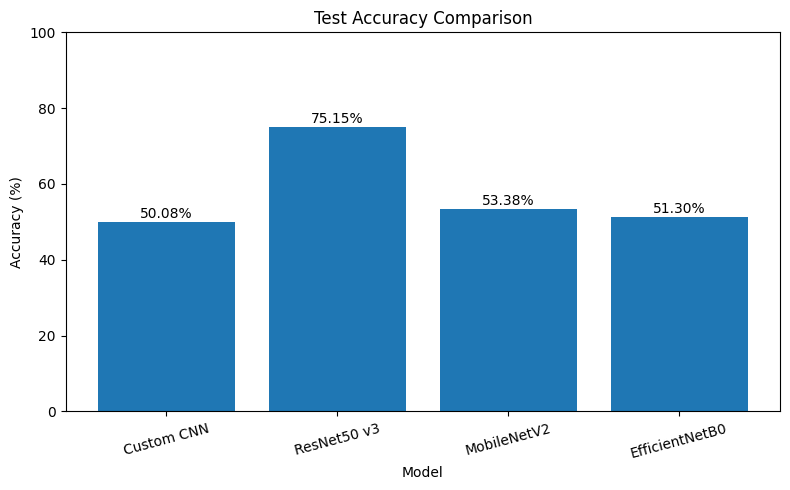

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["Accuracy"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

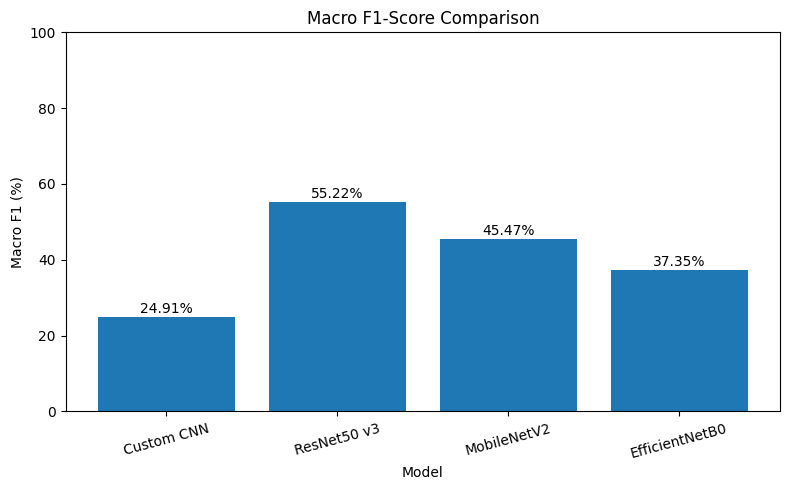

In [5]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"] * 100
)

plt.title("Macro F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("Macro F1 (%)")
plt.ylim(0,100)
plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["Macro F1"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

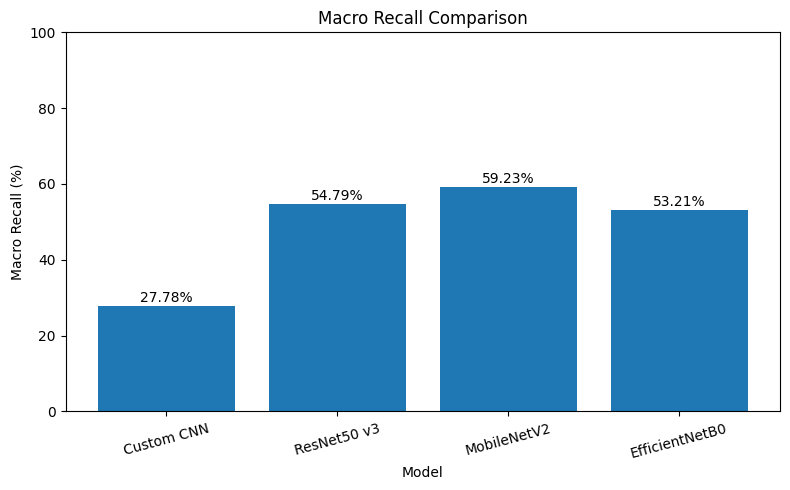

In [6]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Macro Recall"] * 100
)

plt.title("Macro Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Macro Recall (%)")
plt.ylim(0,100)
plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["Macro Recall"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

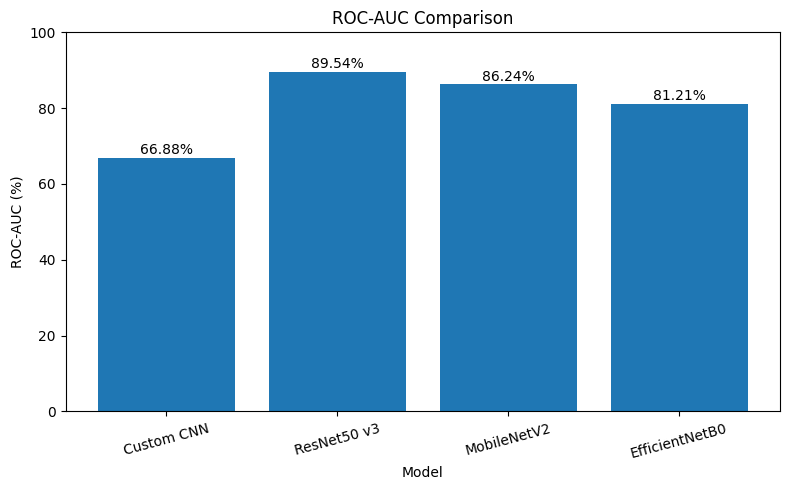

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["ROC-AUC"] * 100
)

plt.title("ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC (%)")
plt.ylim(0,100)
plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["ROC-AUC"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

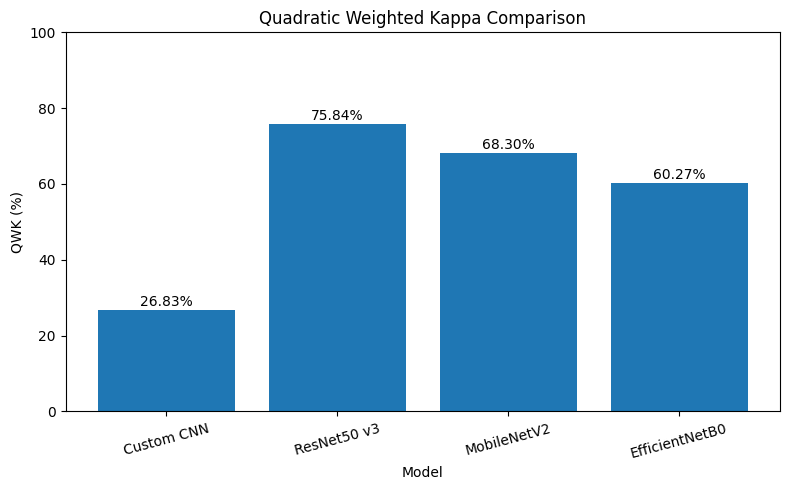

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["QWK"] * 100
)

plt.title("Quadratic Weighted Kappa Comparison")
plt.xlabel("Model")
plt.ylabel("QWK (%)")
plt.ylim(0,100)
plt.xticks(rotation=15)

for i, value in enumerate(comparison_df["QWK"] * 100):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

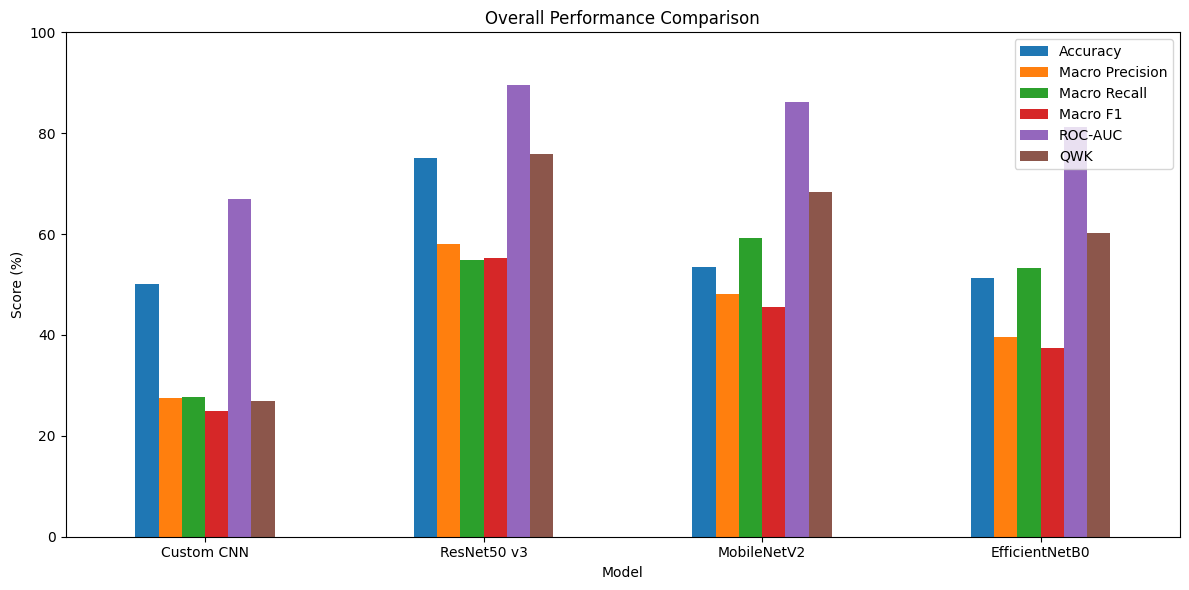

In [9]:
plot_df = comparison_df.set_index("Model")[
    [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "ROC-AUC",
        "QWK"
    ]
] * 100

plot_df.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Overall Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [10]:
class_recall_df = pd.DataFrame({
    "Model": [
        "Custom CNN",
        "ResNet50 v3",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "No DR": [
        0.8691,
        0.9319,
        0.6840,
        0.7426
    ],

    "Mild": [
        0.0842,
        0.0737,
        0.6105,
        0.3684
    ],

    "Moderate": [
        0.1324,
        0.6265,
        0.2738,
        0.1875
    ],

    "Severe": [
        0.1429,
        0.4286,
        0.7143,
        0.8000
    ],

    "Proliferative": [
        0.1606,
        0.6788,
        0.6788,
        0.5620
    ]
})

class_recall_df

,Model,No DR,Mild,Moderate,Severe,Proliferative
0,Custom CNN,0.8691,0.0842,0.1324,0.1429,0.1606
1,ResNet50 v3,0.9319,0.0737,0.6265,0.4286,0.6788
2,MobileNetV2,0.6840,0.6105,0.2738,0.7143,0.6788
3,EfficientNetB0,0.7426,0.3684,0.1875,0.8000,0.5620


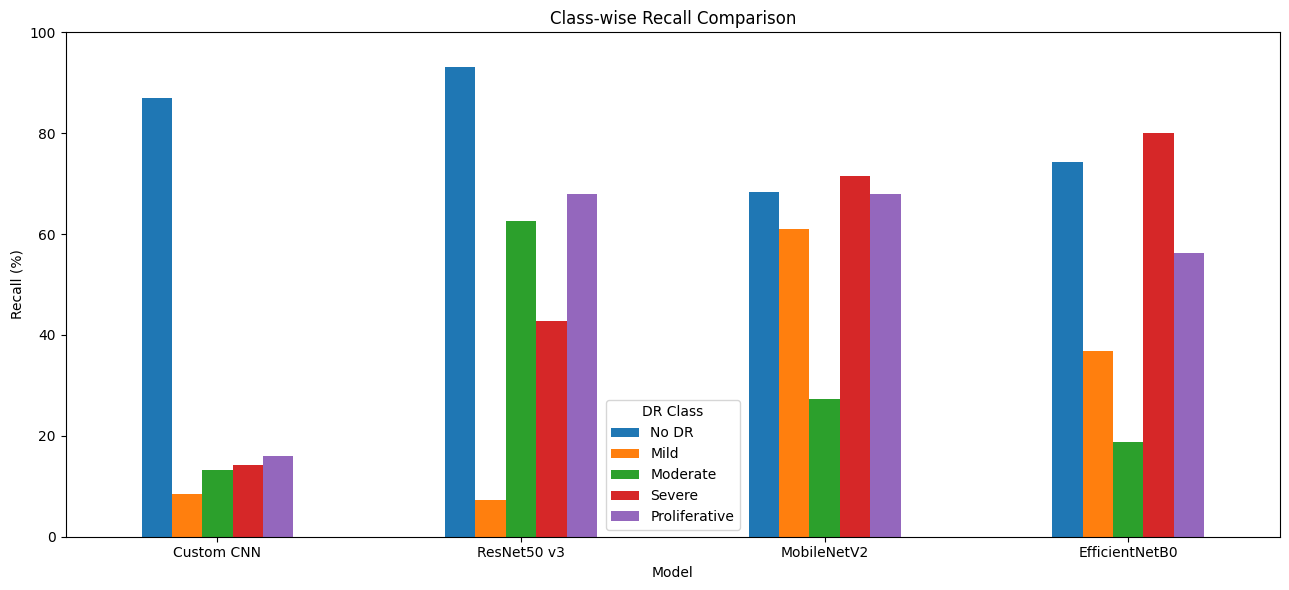

In [11]:
recall_plot = class_recall_df.set_index("Model") * 100

recall_plot.plot(
    kind="bar",
    figsize=(13,6)
)

plt.title("Class-wise Recall Comparison")
plt.ylabel("Recall (%)")
plt.xlabel("Model")
plt.ylim(0,100)
plt.xticks(rotation=0)
plt.legend(title="DR Class")

plt.tight_layout()
plt.show()

In [12]:
metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "ROC-AUC",
    "QWK"
]

for metric in metrics:
    best_row = comparison_df.loc[
        comparison_df[metric].idxmax()
    ]

    print(
        f"{metric}: "
        f"{best_row['Model']} "
        f"({best_row[metric]:.4f})"
    )

Accuracy: ResNet50 v3 (0.7515)
Macro Precision: ResNet50 v3 (0.5798)
Macro Recall: MobileNetV2 (0.5923)
Macro F1: ResNet50 v3 (0.5522)
ROC-AUC: ResNet50 v3 (0.8954)
QWK: ResNet50 v3 (0.7584)


In [13]:
ranking_df = comparison_df[
    [
        "Model",
        "Accuracy",
        "Macro F1",
        "ROC-AUC",
        "QWK"
    ]
].copy()

ranking_df["Average Core Score"] = ranking_df[
    [
        "Accuracy",
        "Macro F1",
        "ROC-AUC",
        "QWK"
    ]
].mean(axis=1)

ranking_df = ranking_df.sort_values(
    "Average Core Score",
    ascending=False
)

ranking_df

,Model,Accuracy,Macro F1,ROC-AUC,QWK,Average Core Score
1,ResNet50 v3,0.751464,0.552219,0.895426,0.758388,0.739374
2,MobileNetV2,0.533795,0.454670,0.862446,0.683000,0.633478
3,EfficientNetB0,0.513039,0.373463,0.812100,0.602730,0.575333
0,Custom CNN,0.500798,0.249079,0.668839,0.268275,0.421748


## Final Comparison Summary

The results show that ResNet50 v3 achieved the strongest overall performance among the four evaluated architectures.

ResNet50 v3 obtained the highest test accuracy, Macro Precision, Macro F1-score, ROC-AUC and Quadratic Weighted Kappa.

MobileNetV2 achieved the highest Macro Recall, indicating better sensitivity across the five classes overall, particularly for minority classes such as Mild and Severe DR.

EfficientNetB0 demonstrated strong recall for Severe DR but showed substantial confusion between Moderate and Severe DR.

The Custom CNN provided a useful baseline but showed strong bias toward the majority No DR class and weaker performance on minority disease classes.

Overall, ResNet50 v3 was selected as the best-performing model because it provided the strongest balance between predictive performance, class discrimination and generalization.

## Critical Analysis

### Custom CNN

The Custom CNN achieved a test accuracy of approximately 50.08% and a Macro F1-score of 24.91%. Although the model classified the No DR class relatively well, it performed poorly on the minority diabetic retinopathy classes.

The training curves showed slow learning and unstable validation behaviour, suggesting underfitting and weak generalization.

### ResNet50 v3

ResNet50 v3 achieved the best overall performance, with 75.15% test accuracy, 55.22% Macro F1-score, 89.54% ROC-AUC and 75.84% QWK.

Fine-tuning significantly improved both training and validation performance. A small train-validation gap appeared toward the final epochs, suggesting mild late-stage overfitting, but the model still demonstrated the strongest generalization.

### MobileNetV2

MobileNetV2 achieved 53.38% test accuracy and 45.47% Macro F1-score.

Although its overall accuracy was lower than ResNet50, it achieved the highest Macro Recall of 59.23%, indicating stronger sensitivity across minority classes.

The second fine-tuning stage improved model stability, although validation performance plateaued toward the later epochs.

### EfficientNetB0

EfficientNetB0 achieved approximately 51.30% test accuracy, 37.35% Macro F1-score and 81.21% ROC-AUC.

The model performed particularly well for Severe DR but frequently confused Moderate DR with Severe DR.

Training-curve analysis was limited because the complete EfficientNetB0 training history was not retained in the available outputs.

In [15]:
comparison_df.to_csv(
    "final_model_comparison.csv",
    index=False
)

class_recall_df.to_csv(
    "class_recall_comparison.csv",
    index=False
)

print("Comparison files saved.")

Comparison files saved.


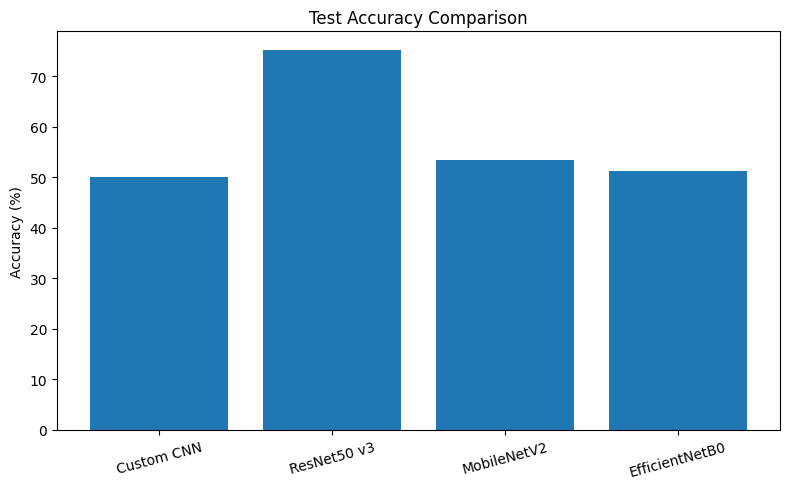

In [16]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

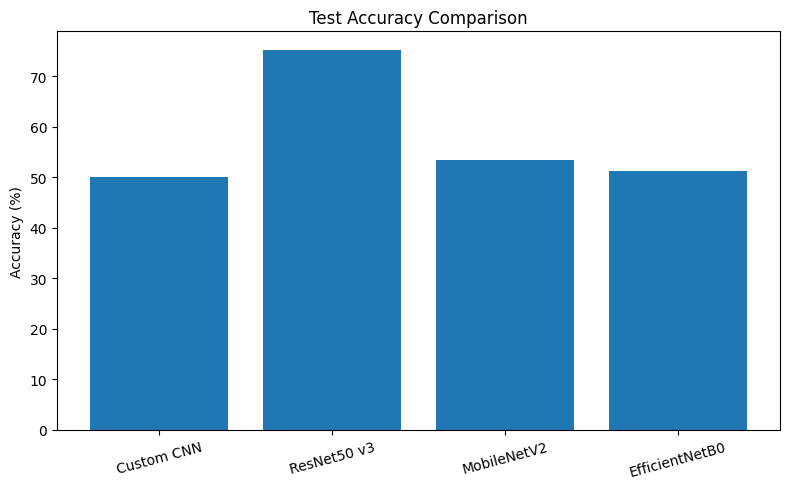

In [17]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "macro_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

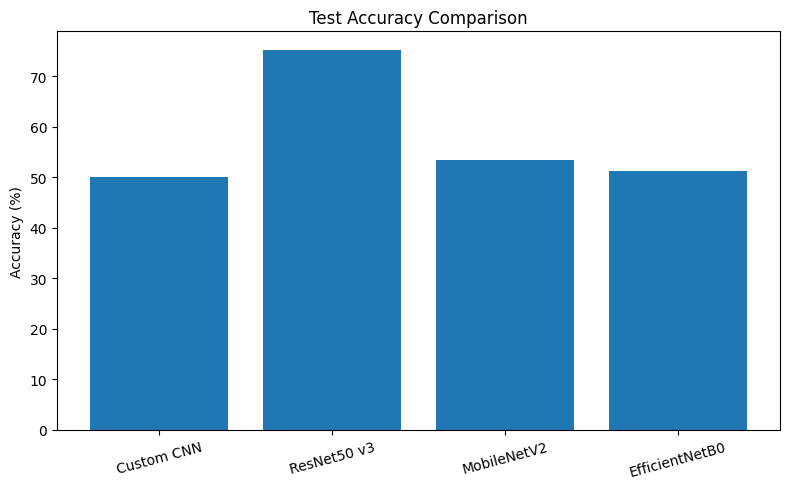

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "macro_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

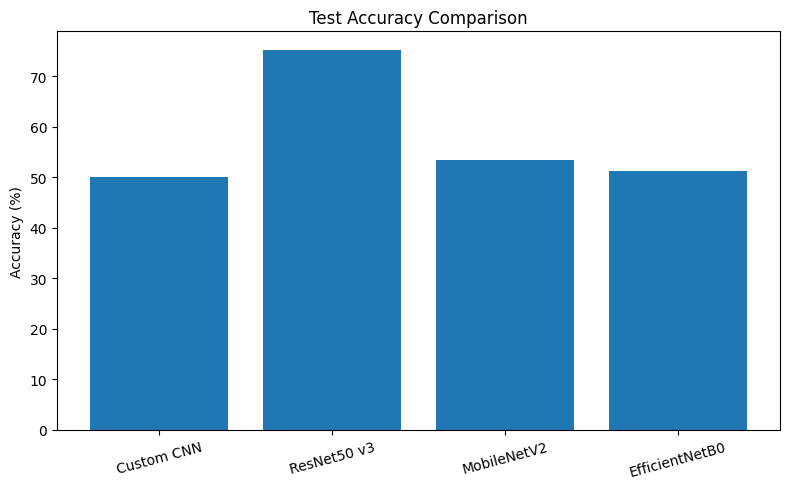

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

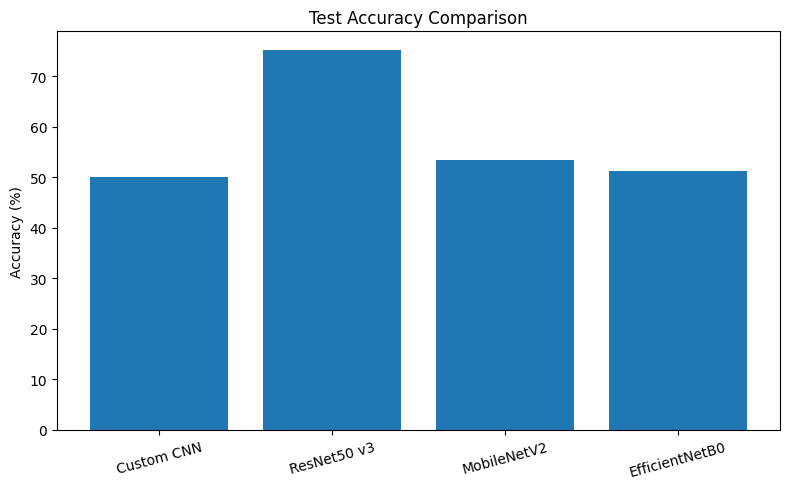

In [20]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "qwk_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

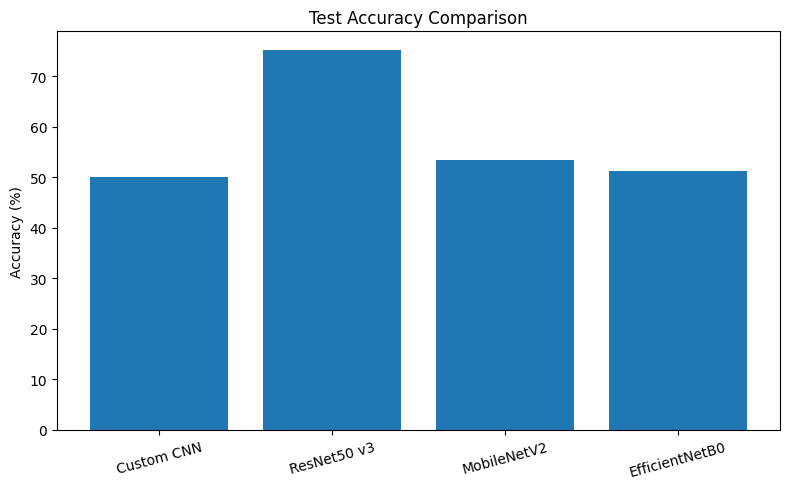

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "class_recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

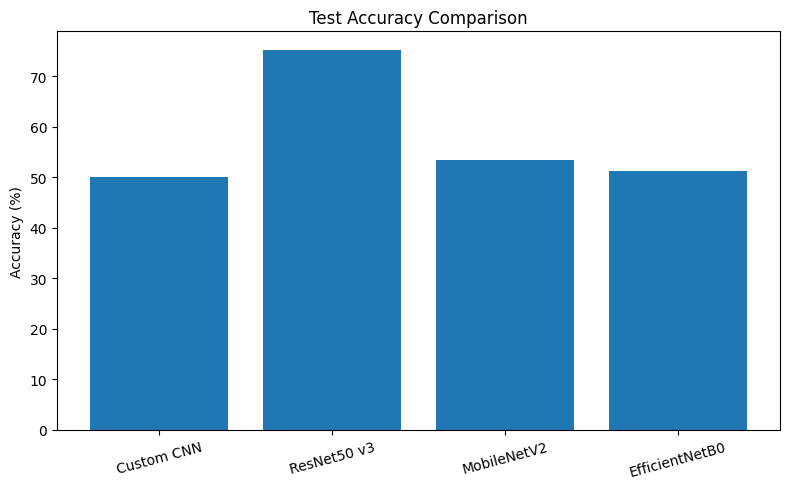

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"] * 100
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "overall_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()